# Multi-Task Learning: PANAS Presence (Task 1) & Likert-Intensitaet (Task 2)

**Gemeinsamer Encoder + drei Heads (Presence, Likert, Cosine-Auxiliary), synchron trainiert (Joint Training).**

## Datenrollen

- `data4training_syn_deep_seek.csv` wird ausschliesslich fuer Train/Validation/Test, Ablation und Checkpoint-Auswahl genutzt.
- Synthetische Rohwerte: `0 = nicht enthalten`, `1-5 = Likert-Intensitaet`; daraus werden Presence-Labels und Likert-Masken gebildet.
- `realdata.csv` wird ausschliesslich als externe Likert-Validierung verwendet; es fliesst nicht in Training, Test oder Checkpoint-Auswahl ein.
- Da der echte Fragebogen alle Items erzwingt, gibt es fuer Realdata keine Presence-Ground-Truth. Presence-Metriken werden dort nicht berechnet; die Coverage zeigt nur, fuer wie viele gueltige Ratings das Modell einen Presence-Score oberhalb des Schwellwerts liefert.
- Reale Likert-Metriken werden nur fuer gueltige Ratings ausgewertet, deren Item der Presence-Head aktiviert. Das ist eine **bedingte** Likert-Auswertung und keine vollstaendige End-to-End-Bewertung.

## Ablation: mit vs. ohne Cosine-Loss

Abschnitt 5 trainiert dieselbe Architektur mehrfach mit `LAMBDA_COSINE = 0.0` (kein Cosine-Loss) und
`LAMBDA_COSINE = 0.5` (mit Cosine-Loss), auf identischem synthetischem Train/Validation/Test-Split. Anschliessend werden beide Checkpoints unabhaengig auf `realdata.csv` anhand der bedingten Likert-Vorhersagen verglichen.

Der Checkpoint wird nach `L_presence + lambda * L_likert` auf dem **Validierungssplit** gewaehlt (**ohne** Cosine-Anteil), damit beide Varianten mit demselben Kriterium verglichen werden. Der synthetische Testsplit wird erst am ausgewaehlten Checkpoint berichtet.

In [5]:
!pip install google-colab

In [6]:
import gc
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from functools import partial
from IPython.display import display
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, mean_absolute_error, mean_squared_error, cohen_kappa_score
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Reproduzierbare Pfad-, Daten- und Trainingskonfiguration
# Die CSV-Dateien liegen neben diesem Notebook.
DATA_PATH = Path("/content/drive/My Drive/Colab Notebooks/EMA2AI/data/data4training_syn_deep_seek.csv")
REAL_DATA_PATH = Path("/content/drive/My Drive/Colab Notebooks/EMA2AI/data/realdata.csv")
CSV_SEP = ";"

# Der synthetische Text steht in Antwort_Text
TEXT_COLUMN = "Antwort_Text"
PANAS_ITEMS = [
    "aktiv", "bekuemmert", "interessiert", "freudig_erregt", "veraergert",
    "stark", "schuldig", "erschrocken", "feindselig", "angeregt",
    "stolz", "gereizt", "begeistert", "beschaemt", "wach", "nervoes",
    "entschlossen", "aufmerksam", "durcheinander", "aengstlich",
]
NUM_ITEMS = len(PANAS_ITEMS)

# Die Realdata nutzt dieselben Items mit deutscher Schreibweise
REAL_TEXT_COLUMN = "audio"
REAL_GROUP_COLUMN = "name"
REAL_PANAS_COLUMNS = [
    "aktiv", "bekümmert", "interessiert", "freudig erregt", "verärgert",
    "stark", "schuldig", "erschrocken", "feindselig", "angeregt",
    "stolz", "gereizt", "begeistert", "beschämt", "wach", "nervös",
    "entschlossen", "aufmerksam", "durcheinander", "ängstlich",
]

# Mehrere Schwellenwerte zeigen den Trade-off zwischen Fehler und Coverage
REAL_PRESENCE_THRESHOLDS = [0.3, 0.5, 0.7, 0.9]
REAL_PRESENCE_THRESHOLD = 0.5

# Die neue Gewichtung bleibt für alle Encoder identisch
POS_WEIGHT_MAX = 20.0
LAMBDA_PRESENCE = 3.0

# BERT und DistilBERT werden unter denselben Trainingsbedingungen verglichen
ENCODER_CONFIGS = {
    "bert": {"model_name": "bert-base-german-cased", "label": "BERT"},
    "distilbert": {"model_name": "distilbert/distilbert-base-german-cased", "label": "DistilBERT"},
}
MODEL_NAME = ENCODER_CONFIGS["bert"]["model_name"]
SIM_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
TEST_SIZE = 0.2
RANDOM_STATE = 42
SEEDS = [42, 43, 44]
EXPERIMENTS = {
    "bert_ohne_cosine": {"encoder": "bert", "lambda_cosine": 0.0},
    "bert_mit_cosine": {"encoder": "bert", "lambda_cosine": 0.5},
    "distilbert_ohne_cosine": {"encoder": "distilbert", "lambda_cosine": 0.0},
    "distilbert_mit_cosine": {"encoder": "distilbert", "lambda_cosine": 0.5},
}

# L_total = lambda_presence * L_presence + lambda_cosine * L_cosine + lambda_likert * L_likert
LAMBDA_LIKERT = 1.0
LAMBDA_COSINE = 0.5
LIKERT_LOSS_TYPE = "mse"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for required_path in (DATA_PATH, REAL_DATA_PATH):
    if not required_path.exists():
        raise FileNotFoundError(
            f"Datendatei nicht gefunden: {required_path}. "
            "Bitte das Notebook aus dem Ordner mit den CSV-Dateien starten."
        )

print(f"Device: {device}")
print(f"Trainingsdaten: {DATA_PATH}")
print(f"Externe Validierungsdaten: {REAL_DATA_PATH}")
print(f"PANAS-Items: {NUM_ITEMS}")
print("Encoder-Vergleich:", ", ".join(config["label"] for config in ENCODER_CONFIGS.values()))

Device: cuda
Trainingsdaten: /content/drive/My Drive/Colab Notebooks/EMA2AI/data/data4training_syn_deep_seek.csv
Externe Validierungsdaten: /content/drive/My Drive/Colab Notebooks/EMA2AI/data/realdata.csv
PANAS-Items: 20
Encoder-Vergleich: BERT, DistilBERT


### Methodische Entscheidung: Datenrollen und Splits

Die synthetischen Daten werden für Training, Validierung und den internen Test verwendet, während die Realdata ausschließlich als externe Validierung dient. Dadurch wird vermieden, dass Informationen aus den echten Daten in das Training oder die Checkpoint-Auswahl gelangen.

Der zusätzliche Validierungssplit ist notwendig, weil der Testsplit nicht zur Auswahl des besten Checkpoints verwendet werden sollte. Andernfalls würde die Testleistung indirekt optimiert und wäre zu positiv eingeschätzt. Mehrere Seeds reduzieren außerdem das Risiko, dass der Vergleich zwischen den Cosine-Loss-Varianten von einer einzelnen Zufallsinitialisierung abhängt.

## 1. Data Pipeline

In [9]:
df_synth = pd.read_csv(DATA_PATH, sep=CSV_SEP, dtype=str)

text_all = df_synth[TEXT_COLUMN].fillna("").to_numpy()

# Rohwerte 0 (nicht enthalten) bis 5 (Likert-Intensität) -> gleichzeitig Regressionsziel
# für Task 2 UND Grundlage für die Presence-Ableitung von Task 1
raw_targets = df_synth[PANAS_ITEMS].apply(pd.to_numeric, errors="coerce")
target_values_all = raw_targets.fillna(0).to_numpy(dtype=np.float32)

# Task 1 (Presence/Gating): 0 = nicht enthalten, 1 = enthalten (Item hat einen Wert 1-5)
target_mask_all = (target_values_all > 0).astype(np.float32)

print(f"Anzahl Samples: {len(text_all)}")
print(f"Presence-Anteil pro Item (Mittelwert über alle Items): {target_mask_all.mean():.3f}")


Anzahl Samples: 1400
Presence-Anteil pro Item (Mittelwert über alle Items): 0.071


In [10]:

sim_model = SentenceTransformer(SIM_MODEL_NAME)
item_embeddings = sim_model.encode(PANAS_ITEMS, normalize_embeddings=True)

def cosine_targets(transcript):
    sentences = [part.strip() for part in str(transcript).split(".") if part.strip()]
    if not sentences:
        return np.zeros(NUM_ITEMS, dtype=np.float32)
    sentence_embeddings = sim_model.encode(sentences, normalize_embeddings=True)
    return util.cos_sim(sentence_embeddings, item_embeddings).cpu().numpy().max(axis=0)

cosine_values_all = np.vstack([cosine_targets(t) for t in text_all]).astype(np.float32)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [11]:
# Train/Validation/Test-Split der synthetischen Daten   ALLE Arrays synchron
# testset bleibt unangetastet für die abschließende interne Bewertung
(text_train_val, text_test,
 target_values_train_val, target_values_test,
 cosine_train_val, cosine_test,
 target_mask_train_val, target_mask_test) = train_test_split(
    text_all, target_values_all, cosine_values_all, target_mask_all,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
(text_train, text_val,
 target_values_train, target_values_val,
 cosine_train, cosine_val,
 target_mask_train, target_mask_val) = train_test_split(
    text_train_val, target_values_train_val, cosine_train_val, target_mask_train_val,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

print(f"Synthetisch: {len(text_train)} Train-Samples | {len(text_val)} Validierungs-Samples | {len(text_test)} Test-Samples")

Synthetisch: 896 Train-Samples | 224 Validierungs-Samples | 280 Test-Samples


In [12]:
# Dataset und DataLoader (synthetisches Train + Validation + Test), dynamisches Padding

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PanasMultiTaskDataset(Dataset):
    """Haelt Rohtexte + Targets; Tokenisierung passiert im collate_fn (dynamic padding)."""

    def __init__(self, texts, target_values, target_mask, cosine_values):
        self.texts = texts
        self.target_values = target_values
        self.target_mask = target_mask
        self.cosine_values = cosine_values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": str(self.texts[idx]),
            "target_values": self.target_values[idx],
            "target_mask": self.target_mask[idx],
            "cosine_values": self.cosine_values[idx],
        }


def collate_fn(batch, tokenizer, max_length):
    texts = [item["text"] for item in batch]
    encodings = tokenizer(
        texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
    )
    target_values = torch.tensor(
        np.stack([item["target_values"] for item in batch]), dtype=torch.float32
    )
    target_mask = torch.tensor(
        np.stack([item["target_mask"] for item in batch]), dtype=torch.float32
    )
    cosine_values = torch.tensor(
        np.stack([item["cosine_values"] for item in batch]), dtype=torch.float32
    )
    return {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "target_values": target_values,
        "target_mask": target_mask,
        "cosine_values": cosine_values,
    }


train_dataset = PanasMultiTaskDataset(text_train, target_values_train, target_mask_train, cosine_train)
val_dataset = PanasMultiTaskDataset(text_val, target_values_val, target_mask_val, cosine_val)
test_dataset = PanasMultiTaskDataset(text_test, target_values_test, target_mask_test, cosine_test)

collate = partial(collate_fn, tokenizer=tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

print(f"Synthetische Train-Batches: {len(train_loader)} | Val-Batches: {len(val_loader)} | Test-Batches: {len(test_loader)}")

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

Synthetische Train-Batches: 112 | Val-Batches: 28 | Test-Batches: 35


In [13]:
# Externe Validierung auf echten Likert-Antworten; nicht zum Training/Splitten verwenden.
real_df = pd.read_csv(REAL_DATA_PATH, sep=CSV_SEP, dtype=str)
missing_real_columns = set([REAL_TEXT_COLUMN, REAL_GROUP_COLUMN, *REAL_PANAS_COLUMNS]).difference(real_df.columns)
if missing_real_columns:
    raise ValueError(f"Fehlende Spalten in Realdata: {sorted(missing_real_columns)}")

real_df = real_df.loc[real_df[REAL_TEXT_COLUMN].fillna("").str.strip().ne("")].reset_index(drop=True)
real_text = real_df[REAL_TEXT_COLUMN].fillna("").to_numpy()
real_groups = real_df[REAL_GROUP_COLUMN].fillna("<missing_name>").to_numpy()
real_raw_targets = real_df[REAL_PANAS_COLUMNS].apply(pd.to_numeric, errors="coerce")
real_target_mask = (
    real_raw_targets.notna() & real_raw_targets.ge(1) & real_raw_targets.le(5)
).to_numpy(dtype=np.float32)
real_target_values = real_raw_targets.fillna(0).to_numpy(dtype=np.float32)
real_cosine_values = np.zeros_like(real_target_values, dtype=np.float32)  # Nicht für Realdata-Metriken verwendet
real_dataset = PanasMultiTaskDataset(
    real_text, real_target_values, real_target_mask, real_cosine_values
)
real_collate = partial(collate_fn, tokenizer=tokenizer, max_length=MAX_LENGTH)
real_loader = DataLoader(
    real_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=real_collate
)
print(f"Externe Realdata-Validierung: {len(real_dataset)} Transkripte")
print(f"Eindeutige Personen/Name-Gruppen: {pd.Series(real_groups).nunique()}")
print(f"Gültige Likert-Ratings: {int(real_target_mask.sum())}")

invalid_real_values = real_raw_targets.notna() & ~(real_raw_targets.ge(1) & real_raw_targets.le(5))
invalid_count = int(invalid_real_values.to_numpy().sum())
missing_count = int(real_raw_targets.isna().to_numpy().sum())
real_token_lengths = [
    len(tokenizer(str(text), add_special_tokens=True, truncation=False)["input_ids"])
    for text in real_text
]
truncated_count = sum(length > MAX_LENGTH for length in real_token_lengths)
print("\n" + "!" * 78)
print("DATENQUALITÄT / TRUNCATION-CHECK")
print(f"Ungültige Likert-Werte außerhalb 1..5: {invalid_count}")
print(f"Fehlende Likert-Werte: {missing_count}")
print(f"Transkripte länger als MAX_LENGTH={MAX_LENGTH}: {truncated_count}/{len(real_text)}")
if truncated_count:
    print("WARNUNG: Diese Transkripte werden für das Modell abgeschnitten. MAX_LENGTH=512 als Sensitivitätsanalyse prüfen.")
else:
    print("OK: Kein Realdata-Transkript überschreitet MAX_LENGTH.")
print("!" * 78)

Externe Realdata-Validierung: 120 Transkripte
Eindeutige Personen/Name-Gruppen: 36
Gültige Likert-Ratings: 2180

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DATENQUALITÄT / TRUNCATION-CHECK
Ungültige Likert-Werte außerhalb 1..5: 0
Fehlende Likert-Werte: 220
Transkripte länger als MAX_LENGTH=256: 11/120
WARNUNG: Diese Transkripte werden für das Modell abgeschnitten. MAX_LENGTH=512 als Sensitivitätsanalyse prüfen.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


### Methodische Entscheidung: Externe Validierung

Die Realdata enthält echte Audio-Transkripte und Likert-Werte, aber keine unabhängige Ground Truth dafür, ob ein PANAS-Item im gesprochenen Text tatsächlich genannt wurde. Deshalb werden auf diesen Daten keine Presence-F1- oder AUROC-Werte berichtet.

Stattdessen werden zwei Likert-Perspektiven getrennt betrachtet: Bei der **Oracle-Auswertung** wird die Item-Erkennung als perfekt angenommen. Das misst die reine Qualität des Likert-Heads. Bei der **conditional-Auswertung** werden nur Items bewertet, die der Presence-Head auswählt. Diese Auswertung ist näher an der späteren Anwendung, kann aber durch die Detection-Auswahl verzerrt sein.

## 2. Modell-Architektur

In [14]:
class BertMultiTaskModel(nn.Module):
    """Gemeinsamer Transformer-Encoder + drei Prediction-Heads."""

    def __init__(self, model_name, num_items, dropout=0.1):
        super().__init__()
        # encoder wird je Experiment aus der Konfiguration geladen
        self.encoder = AutoModel.from_pretrained(model_name, dtype=torch.float32).float()
        hidden_size = self.encoder.config.hidden_size

        # dropout soll bei den kleinen daten bisschen gegen overfitting helfen
        self.dropout = nn.Dropout(dropout)
        # Kommentar 3: Jeder Head gibt pro PANAS-Item genau einen Wert zurück.
        self.presence_head = nn.Linear(hidden_size, num_items)
        self.likert_head = nn.Linear(hidden_size, num_items)
        self.cosine_head = nn.Linear(hidden_size, num_items)

    def forward(self, input_ids, attention_mask):
        # attention-maske verhindert, dass Padding den Encoder beeinflusst
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = self.dropout(outputs.last_hidden_state[:, 0, :])

        # die gemeinsame CLS-Repräsentation wird an alle drei Aufgaben gegeben
        presence_logits = self.presence_head(cls_repr)
        likert_pred = self.likert_head(cls_repr)
        cosine_pred = self.cosine_head(cls_repr)
        return presence_logits, likert_pred, cosine_pred

    @torch.no_grad()
    def predict_presence_proba(self, input_ids, attention_mask):
        presence_logits, _, _ = self.forward(input_ids, attention_mask)
        return torch.sigmoid(presence_logits)

## 3. Loss-Funktionen & Maskierung

In [15]:
# Presence-Gewichte nur aus dem synthetischen Trainingssplit berechnen
# pos_weight > 1 bestraft verpasste positive Items stärker als negative Items
positive_counts = target_mask_train.sum(axis=0)
negative_counts = len(target_mask_train) - positive_counts
presence_pos_weight = np.divide(
    negative_counts,
    positive_counts,
    out=np.ones_like(positive_counts, dtype=np.float32),
    where=positive_counts > 0,
)
presence_pos_weight = np.clip(presence_pos_weight, 1.0, POS_WEIGHT_MAX).astype(np.float32)
presence_pos_weight_tensor = torch.tensor(presence_pos_weight, dtype=torch.float32, device=device)
presence_loss_fn = nn.BCEWithLogitsLoss(
    reduction="none", pos_weight=presence_pos_weight_tensor
)
cosine_loss_fn = nn.MSELoss()  # auf allen Samples/Items, ungemaskt

if LIKERT_LOSS_TYPE == "huber":
    likert_loss_fn = nn.SmoothL1Loss(reduction="none", beta=1.0)
else:
    likert_loss_fn = nn.MSELoss(reduction="none")

print("Presence pos_weight pro Item:")
display(pd.DataFrame({"item": PANAS_ITEMS, "positive_count": positive_counts.astype(int), "pos_weight": presence_pos_weight}).round(3))
print(f"LAMBDA_PRESENCE={LAMBDA_PRESENCE}: Presence-Loss wird im Gesamtgradienten höher gewichtet.")


def compute_losses(presence_logits, likert_pred, cosine_pred,
                   target_mask, target_values, cosine_values,
                   lambda_likert=LAMBDA_LIKERT, lambda_cosine=LAMBDA_COSINE,
                   lambda_presence=LAMBDA_PRESENCE):
    """L_total = lambda_presence * L_presence + lambda_cosine * L_cosine + lambda_likert * L_likert."""

    # Task 1: gewichtetes BCE auf der vollständigen Presence-Maske
    loss_presence = presence_loss_fn(presence_logits, target_mask).mean()

    # Auxiliary: Cosine-Regression auf allen Items (Regularisierung)
    loss_cosine = cosine_loss_fn(cosine_pred, cosine_values)

    # Task 2: Likert     STRENG maskiert, nur Items mit target_mask == 1
    raw_likert_loss = likert_loss_fn(likert_pred, target_values)
    valid_items = target_mask.sum().clamp(min=1)
    loss_likert = (raw_likert_loss * target_mask).sum() / valid_items

    loss_total = (lambda_presence * loss_presence
                  + lambda_cosine * loss_cosine
                  + lambda_likert * loss_likert)
    parts = {
        "loss_presence": loss_presence.detach(),
        "loss_cosine": loss_cosine.detach(),
        "loss_likert": loss_likert.detach(),
    }
    return loss_total, parts

Presence pos_weight pro Item:


,item,positive_count,pos_weight
0,aktiv,36,20.000000
1,bekuemmert,89,9.067000
2,interessiert,50,16.920000
3,freudig_erregt,183,3.896000
4,veraergert,95,8.432000
5,stark,40,20.000000
6,schuldig,1,20.000000
7,erschrocken,6,20.000000
8,feindselig,47,18.063999
9,angeregt,74,11.108000


LAMBDA_PRESENCE=3.0: Presence-Loss wird im Gesamtgradienten höher gewichtet.


### Methodische Entscheidung: Multi-Task-Loss und Klassenungleichgewicht

Das Modell lernt Presence und Likert gemeinsam, weil beide Aufgaben inhaltlich zusammenhängen: Ein Item kann nur dann eine Likert-Intensität besitzen, wenn es im Text vorhanden ist. Der Likert-Loss wird deshalb auf gültige Items maskiert.

Die Presence-Ziele sind stark unausgeglichen. Ohne Korrektur kann das Modell fast immer die negative Klasse vorhersagen und trotzdem einen kleinen BCE-Loss erreichen. Deshalb verwendet das BCE ein per Item berechnetes `pos_weight = negative / positive`, das nur aus dem Trainingssplit stammt. Zusätzlich wird der Presence-Anteil der Gesamt-Loss mit `LAMBDA_PRESENCE = 3.0` verstärkt. Die Obergrenze `POS_WEIGHT_MAX = 20` verhindert, dass extrem seltene Items den gesamten Gradient dominieren.

Der Cosine-Loss wird nur als Auxiliary-Loss untersucht. Er soll die semantische Repräsentation unterstützen, ist aber kein direktes Gütemaß für die PANAS-Likert-Skala. Deshalb wird seine Wirkung über die Ablation mit und ohne Cosine-Loss verglichen, statt ihn als primäre Zielgröße zu interpretieren.

## 4. Training & Validierung

In [16]:
def _to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}


def train_epoch(model, loader, optimizer, scheduler, device,
                lambda_likert=LAMBDA_LIKERT, lambda_cosine=LAMBDA_COSINE,
                lambda_presence=LAMBDA_PRESENCE):
    """Ein Trainings-Epoch ueber den gesamten train_loader."""
    model.train()
    running = {"loss": 0.0, "loss_presence": 0.0, "loss_cosine": 0.0, "loss_likert": 0.0}

    for batch in loader:
        batch = _to_device(batch, device)

        optimizer.zero_grad()
        presence_logits, likert_pred, cosine_pred = model(batch["input_ids"], batch["attention_mask"])

        loss, parts = compute_losses(
            presence_logits, likert_pred, cosine_pred,
            batch["target_mask"], batch["target_values"], batch["cosine_values"],
            lambda_likert, lambda_cosine, lambda_presence,
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running["loss"] += loss.item()
        for k, v in parts.items():
            running[k] += v.item()

    n = len(loader)
    return {k: v / n for k, v in running.items()}


@torch.no_grad()
def evaluate(model, loader, device,
             lambda_likert=LAMBDA_LIKERT, lambda_cosine=LAMBDA_COSINE,
             lambda_presence=LAMBDA_PRESENCE):
    """Loss und Metriken fuer synthetisches Testset oder externe Realdata."""
    model.eval()
    running = {"loss": 0.0, "loss_presence": 0.0, "loss_cosine": 0.0, "loss_likert": 0.0}

    all_presence_true, all_presence_prob = [], []
    all_likert_true, all_likert_pred, all_likert_mask = [], [], []
    all_cosine_true, all_cosine_pred = [], []

    for batch in loader:
        batch = _to_device(batch, device)

        presence_logits, likert_pred, cosine_pred = model(batch["input_ids"], batch["attention_mask"])
        loss, parts = compute_losses(
            presence_logits, likert_pred, cosine_pred,
            batch["target_mask"], batch["target_values"], batch["cosine_values"],
            lambda_likert, lambda_cosine, lambda_presence,
        )

        running["loss"] += loss.item()
        for k, v in parts.items():
            running[k] += v.item()

        all_presence_true.append(batch["target_mask"].cpu().numpy())
        all_presence_prob.append(torch.sigmoid(presence_logits).cpu().numpy())
        all_likert_true.append(batch["target_values"].cpu().numpy())
        all_likert_pred.append(likert_pred.cpu().numpy())
        all_likert_mask.append(batch["target_mask"].cpu().numpy())
        all_cosine_true.append(batch["cosine_values"].cpu().numpy())
        all_cosine_pred.append(cosine_pred.cpu().numpy())

    n = len(loader)
    presence_true = np.concatenate(all_presence_true, axis=0)
    presence_prob = np.concatenate(all_presence_prob, axis=0)
    presence_pred = (presence_prob > 0.5).astype(np.float32)

    f1 = f1_score(presence_true, presence_pred, average="macro", zero_division=0)
    acc = accuracy_score(presence_true.flatten(), presence_pred.flatten())
    item_aurocs = [
        roc_auc_score(presence_true[:, item_index], presence_prob[:, item_index])
        for item_index in range(NUM_ITEMS)
        if np.unique(presence_true[:, item_index]).size == 2
    ]
    auroc = float(np.mean(item_aurocs)) if item_aurocs else float("nan")

    likert_true = np.concatenate(all_likert_true, axis=0).flatten()
    likert_pred_flat = np.concatenate(all_likert_pred, axis=0).flatten()
    likert_mask_flat = np.concatenate(all_likert_mask, axis=0).flatten().astype(bool)
    if likert_mask_flat.sum() > 0:
        mae = mean_absolute_error(likert_true[likert_mask_flat], likert_pred_flat[likert_mask_flat])
        rmse = np.sqrt(mean_squared_error(likert_true[likert_mask_flat], likert_pred_flat[likert_mask_flat]))
    else:
        mae, rmse = float("nan"), float("nan")

    cosine_mae = mean_absolute_error(
        np.concatenate(all_cosine_true, axis=0).flatten(),
        np.concatenate(all_cosine_pred, axis=0).flatten(),
    )

    metrics = {k: v / n for k, v in running.items()}
    metrics["loss_main"] = metrics["loss_presence"] * lambda_presence + lambda_likert * metrics["loss_likert"]
    metrics.update({
        "task1_f1": f1,
        "task1_auroc": auroc,
        "task1_auroc_items": len(item_aurocs),
        "task1_accuracy": acc,
        "task2_mae": mae,
        "task2_rmse": rmse,
        "aux_cosine_mae": cosine_mae,
    })
    return metrics

## 5. Ablation: Training mit vs. ohne Cosine-Loss

In [17]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_model_loaders(model_name):
    """Erzeugt pro Encoder einen passenden Tokenizer und identische Loader."""
    # Jeder Encoder bekommt seinen eigenen passenden Tokenizer
    model_tokenizer = AutoTokenizer.from_pretrained(model_name)
    model_collate = partial(collate_fn, tokenizer=model_tokenizer, max_length=MAX_LENGTH)
    # text und target-splits bleiben für alle Encoder gleich
    model_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=model_collate)
    model_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=model_collate)
    model_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=model_collate)
    # Auch die externe Realdata wird nur neu tokenisiert, nicht neu bewertet
    model_real_loader = DataLoader(real_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=model_collate)
    # so unterscheiden sich die Ansätze nur durch Encoder und Cosine-Loss
    return model_tokenizer, model_train_loader, model_val_loader, model_test_loader, model_real_loader


def train_epoch(model, loader, optimizer, scheduler, device,
                lambda_likert=LAMBDA_LIKERT, lambda_cosine=LAMBDA_COSINE,
                lambda_presence=LAMBDA_PRESENCE):
    """Ein Trainings-Epoch ueber den gesamten train_loader."""
    model.train()
    running = {"loss": 0.0, "loss_presence": 0.0, "loss_cosine": 0.0, "loss_likert": 0.0}

    for batch in loader:
        batch = _to_device(batch, device)
        optimizer.zero_grad()
        presence_logits, likert_pred, cosine_pred = model(batch["input_ids"], batch["attention_mask"])
        loss, parts = compute_losses(
            presence_logits, likert_pred, cosine_pred,
            batch["target_mask"], batch["target_values"], batch["cosine_values"],
            lambda_likert, lambda_cosine, lambda_presence,
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running["loss"] += loss.item()
        for key, value in parts.items():
            running[key] += value.item()

    n = len(loader)
    return {key: value / n for key, value in running.items()}


@torch.no_grad()
def evaluate(model, loader, device,
             lambda_likert=LAMBDA_LIKERT, lambda_cosine=LAMBDA_COSINE,
             lambda_presence=LAMBDA_PRESENCE):
    """Loss und Metriken fuer synthetisches Testset oder externe Realdata."""
    model.eval()
    running = {"loss": 0.0, "loss_presence": 0.0, "loss_cosine": 0.0, "loss_likert": 0.0}
    all_presence_true, all_presence_prob = [], []
    all_likert_true, all_likert_pred, all_likert_mask = [], [], []
    all_cosine_true, all_cosine_pred = [], []

    for batch in loader:
        batch = _to_device(batch, device)
        presence_logits, likert_pred, cosine_pred = model(batch["input_ids"], batch["attention_mask"])
        loss, parts = compute_losses(
            presence_logits, likert_pred, cosine_pred,
            batch["target_mask"], batch["target_values"], batch["cosine_values"],
            lambda_likert, lambda_cosine, lambda_presence,
        )
        running["loss"] += loss.item()
        for key, value in parts.items():
            running[key] += value.item()

        all_presence_true.append(batch["target_mask"].cpu().numpy())
        all_presence_prob.append(torch.sigmoid(presence_logits).cpu().numpy())
        all_likert_true.append(batch["target_values"].cpu().numpy())
        all_likert_pred.append(likert_pred.cpu().numpy())
        all_likert_mask.append(batch["target_mask"].cpu().numpy())
        all_cosine_true.append(batch["cosine_values"].cpu().numpy())
        all_cosine_pred.append(cosine_pred.cpu().numpy())

    n = len(loader)
    presence_true = np.concatenate(all_presence_true, axis=0)
    presence_prob = np.concatenate(all_presence_prob, axis=0)
    presence_pred = (presence_prob > 0.5).astype(np.float32)
    f1 = f1_score(presence_true, presence_pred, average="macro", zero_division=0)
    acc = accuracy_score(presence_true.flatten(), presence_pred.flatten())
    item_aurocs = [
        roc_auc_score(presence_true[:, item_index], presence_prob[:, item_index])
        for item_index in range(NUM_ITEMS)
        if np.unique(presence_true[:, item_index]).size == 2
    ]
    auroc = float(np.mean(item_aurocs)) if item_aurocs else float("nan")

    likert_true = np.concatenate(all_likert_true, axis=0).flatten()
    likert_pred_flat = np.concatenate(all_likert_pred, axis=0).flatten()
    likert_mask_flat = np.concatenate(all_likert_mask, axis=0).flatten().astype(bool)
    if likert_mask_flat.sum() > 0:
        mae = mean_absolute_error(likert_true[likert_mask_flat], likert_pred_flat[likert_mask_flat])
        rmse = np.sqrt(mean_squared_error(likert_true[likert_mask_flat], likert_pred_flat[likert_mask_flat]))
    else:
        mae, rmse = float("nan"), float("nan")

    cosine_mae = mean_absolute_error(
        np.concatenate(all_cosine_true, axis=0).flatten(),
        np.concatenate(all_cosine_pred, axis=0).flatten(),
    )
    metrics = {key: value / n for key, value in running.items()}
    metrics["loss_main"] = metrics["loss_presence"] * lambda_presence + lambda_likert * metrics["loss_likert"]
    metrics.update({
        "task1_f1": f1,
        "task1_auroc": auroc,
        "task1_auroc_items": len(item_aurocs),
        "task1_accuracy": acc,
        "task2_mae": mae,
        "task2_rmse": rmse,
        "aux_cosine_mae": cosine_mae,
    })
    return metrics


def run_experiment(name, encoder_key, lambda_cosine, seed, epochs=EPOCHS):
    """Trainiert einen Encoder und waehlt den Checkpoint auf der Validation."""
    set_seed(seed)
    model_name = ENCODER_CONFIGS[encoder_key]["model_name"]
    # Vor jedem Lauf werden Seed, Modell und Optimizer neu gesetzt
    model_tokenizer, model_train_loader, model_val_loader, model_test_loader, model_real_loader = build_model_loaders(model_name)
    model = BertMultiTaskModel(model_name, num_items=NUM_ITEMS).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(model_train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * WARMUP_RATIO),
        num_training_steps=total_steps,
    )

    ckpt_path = f"best_{name}_seed{seed}.pt"
    best_main_loss, best, best_test, history = float("inf"), None, None, []
    for epoch in range(1, epochs + 1):
        train_metrics = train_epoch(
            model, model_train_loader, optimizer, scheduler, device,
            LAMBDA_LIKERT, lambda_cosine, LAMBDA_PRESENCE,
        )
        val_metrics = evaluate(
            model, model_val_loader, device,
            LAMBDA_LIKERT, lambda_cosine, LAMBDA_PRESENCE,
        )
        test_metrics = evaluate(
            model, model_test_loader, device,
            LAMBDA_LIKERT, lambda_cosine, LAMBDA_PRESENCE,
        )
        history.append({"epoch": epoch, "train": train_metrics, "val": val_metrics, "test": test_metrics})
        print(
            f"[{name} | seed {seed}] Epoch {epoch}/{epochs} | "
            f"Train={train_metrics['loss']:.4f} | Val main={val_metrics['loss_main']:.4f} "
            f"F1={val_metrics['task1_f1']:.3f} MAE={val_metrics['task2_mae']:.3f} | "
            f"Test F1={test_metrics['task1_f1']:.3f} MAE={test_metrics['task2_mae']:.3f}"
        )
        if val_metrics["loss_main"] < best_main_loss:
            best_main_loss = val_metrics["loss_main"]
            best = {**val_metrics, "epoch": epoch}
            best_test = {**test_metrics, "epoch": epoch}
            torch.save(model.state_dict(), ckpt_path)

    del model, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        "name": name,
        "encoder": encoder_key,
        "model_name": model_name,
        "seed": seed,
        "lambda_cosine": lambda_cosine,
        "ckpt_path": ckpt_path,
        "tokenizer": model_tokenizer,
        "real_loader": model_real_loader,
        "best": best,
        "best_test": best_test,
        "history": history,
    }


all_runs = []
for seed in SEEDS:
    for name, experiment in EXPERIMENTS.items():
        print("=" * 100)
        print(f"Experiment: {name} | seed={seed}")
        print("=" * 100)
        all_runs.append(run_experiment(name, experiment["encoder"], experiment["lambda_cosine"], seed))

Experiment: bert_ohne_cosine | seed=42


model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[distilbert_ohne_cosine | seed 44] Epoch 1/5 | Train=12.7487 | Val main=4.0326 F1=0.244 MAE=0.823 | Test F1=0.232 MAE=0.815
[distilbert_ohne_cosine | seed 44] Epoch 2/5 | Train=2.8709 | Val main=2.0771 F1=0.459 MAE=0.410 | Test F1=0.441 MAE=0.422
[distilbert_ohne_cosine | seed 44] Epoch 3/5 | Train=1.8244 | Val main=1.6017 F1=0.641 MAE=0.356 | Test F1=0.618 MAE=0.376
[distilbert_ohne_cosine | seed 44] Epoch 4/5 | Train=1.4237 | Val main=1.3459 F1=0.730 MAE=0.333 | Test F1=0.676 MAE=0.366
[distilbert_ohne_cosine | seed 44] Epoch 5/5 | Train=1.2351 | Val main=1.2879 F1=0.738 MAE=0.317 | Test F1=0.704 MAE=0.351
Experiment: distilbert_mit_cosine | seed=44


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[distilbert_mit_cosine | seed 44] Epoch 1/5 | Train=12.8278 | Val main=4.0399 F1=0.247 MAE=0.825 | Test F1=0.234 MAE=0.816
[distilbert_mit_cosine | seed 44] Epoch 2/5 | Train=2.9141 | Val main=2.0869 F1=0.454 MAE=0.410 | Test F1=0.436 MAE=0.423
[distilbert_mit_cosine | seed 44] Epoch 3/5 | Train=1.8682 | Val main=1.6110 F1=0.637 MAE=0.357 | Test F1=0.617 MAE=0.376
[distilbert_mit_cosine | seed 44] Epoch 4/5 | Train=1.4659 | Val main=1.3523 F1=0.725 MAE=0.332 | Test F1=0.672 MAE=0.364
[distilbert_mit_cosine | seed 44] Epoch 5/5 | Train=1.2766 | Val main=1.2941 F1=0.731 MAE=0.318 | Test F1=0.696 MAE=0.350


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Externe Validierung auf real_data.csv; Presence wird nicht bewertet.
Likert-Auswertung nur bei Presence-Score >= 0.50.


,experiment,encoder,seed,best_epoch_synthetic,valid_ratings,evaluated_ratings,coverage,likert_mae,likert_rmse,rounded_accuracy,mean_item_qwk
0,bert_ohne_cosine,bert,42,5,2180,416,0.1908,1.2696,1.5186,0.2115,0.0295
1,bert_mit_cosine,bert,42,5,2180,414,0.1899,1.2572,1.5080,0.2222,0.0532
2,distilbert_ohne_cosine,distilbert,42,5,2180,486,0.2229,1.2217,1.4174,0.2099,0.0896
3,distilbert_mit_cosine,distilbert,42,5,2180,489,0.2243,1.2208,1.4143,0.2065,0.1115
4,bert_ohne_cosine,bert,43,5,2180,342,0.1569,1.3298,1.6003,0.2105,0.1196
5,bert_mit_cosine,bert,43,5,2180,344,0.1578,1.3298,1.5974,0.2209,0.1389
6,distilbert_ohne_cosine,distilbert,43,5,2180,415,0.1904,1.3173,1.5308,0.1855,0.1704
7,distilbert_mit_cosine,distilbert,43,5,2180,408,0.1872,1.3271,1.5402,0.1887,0.1812
8,bert_ohne_cosine,bert,44,5,2180,432,0.1982,1.4336,1.6946,0.1921,0.0810
9,bert_mit_cosine,bert,44,5,2180,437,0.2005,1.4461,1.7055,0.1854,0.0674


Itemweise externe Likert-Metriken:


,experiment,encoder,seed,item,valid_ratings,detected_ratings,coverage,MAE,RMSE,rounded_accuracy,QWK
0,bert_ohne_cosine,bert,42,aktiv,109,17,0.156,0.990,1.206,0.235,-0.203
1,bert_ohne_cosine,bert,42,bekümmert,109,65,0.596,1.618,1.780,0.062,0.029
2,bert_ohne_cosine,bert,42,interessiert,109,1,0.009,0.766,0.766,0.000,NaN
3,bert_ohne_cosine,bert,42,freudig erregt,109,59,0.541,1.157,1.527,0.271,0.033
4,bert_ohne_cosine,bert,42,verärgert,109,4,0.037,1.977,2.038,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
235,distilbert_mit_cosine,distilbert,44,nervös,109,67,0.615,1.407,1.565,0.149,0.092
236,distilbert_mit_cosine,distilbert,44,entschlossen,109,0,0.000,NaN,NaN,NaN,NaN
237,distilbert_mit_cosine,distilbert,44,aufmerksam,109,1,0.009,0.301,0.301,1.000,NaN
238,distilbert_mit_cosine,distilbert,44,durcheinander,109,81,0.743,1.260,1.457,0.185,-0.021


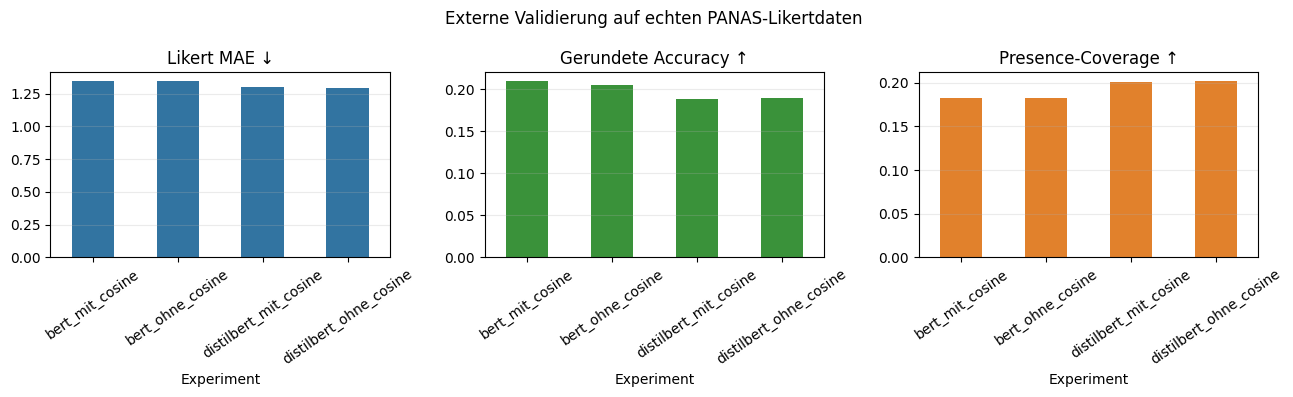

In [18]:
# ---------------------------------------------------------------------------
# Externe Realdata-Validierung: nur Likert auf Presence-erkannten Items
# ---------------------------------------------------------------------------
def evaluate_real_likert(model, loader, device, presence_threshold=REAL_PRESENCE_THRESHOLD):
    model.eval()
    all_true, all_pred, all_detected, all_valid = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = _to_device(batch, device)
            presence_logits, likert_pred, _ = model(batch["input_ids"], batch["attention_mask"])
            detected = torch.sigmoid(presence_logits) >= presence_threshold
            all_true.append(batch["target_values"].cpu().numpy())
            all_pred.append(likert_pred.cpu().numpy())
            all_detected.append(detected.cpu().numpy())
            all_valid.append(batch["target_mask"].cpu().numpy().astype(bool))

    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.clip(np.concatenate(all_pred, axis=0), 1.0, 5.0)
    detected = np.concatenate(all_detected, axis=0).astype(bool)
    valid = np.concatenate(all_valid, axis=0).astype(bool)
    selected = detected & valid

    true_selected = y_true[selected]
    pred_selected = y_pred[selected]
    rounded_pred = np.clip(np.floor(pred_selected + 0.5), 1, 5).astype(int)
    rounded_true = true_selected.astype(int)
    if len(true_selected):
        overall = {
            "valid_ratings": int(valid.sum()),
            "evaluated_ratings": int(selected.sum()),
            "coverage": float(selected.sum() / max(valid.sum(), 1)),
            "likert_mae": float(mean_absolute_error(true_selected, pred_selected)),
            "likert_rmse": float(np.sqrt(mean_squared_error(true_selected, pred_selected))),
            "rounded_accuracy": float(accuracy_score(rounded_true, rounded_pred)),
        }
    else:
        overall = {"valid_ratings": int(valid.sum()), "evaluated_ratings": 0, "coverage": 0.0,
                   "likert_mae": np.nan, "likert_rmse": np.nan, "rounded_accuracy": np.nan}

    item_rows = []
    item_qwks = []
    for item_index, item in enumerate(REAL_PANAS_COLUMNS):
        item_valid = valid[:, item_index]
        item_selected = selected[:, item_index]
        item_true = y_true[item_selected, item_index].astype(int)
        item_pred = np.clip(np.floor(y_pred[item_selected, item_index] + 0.5), 1, 5).astype(int)
        qwk = np.nan
        if len(item_true) and np.unique(item_true).size > 1:
            qwk = cohen_kappa_score(item_true, item_pred, weights="quadratic")
            if np.isfinite(qwk):
                item_qwks.append(qwk)
        item_rows.append({
            "item": item,
            "valid_ratings": int(item_valid.sum()),
            "detected_ratings": int(item_selected.sum()),
            "coverage": float(item_selected.sum() / max(item_valid.sum(), 1)),
            "MAE": float(mean_absolute_error(y_true[item_selected, item_index], y_pred[item_selected, item_index])) if item_selected.any() else np.nan,
            "RMSE": float(np.sqrt(mean_squared_error(y_true[item_selected, item_index], y_pred[item_selected, item_index])) if item_selected.any() else np.nan),
            "rounded_accuracy": float(accuracy_score(item_true, item_pred)) if len(item_true) else np.nan,
            "QWK": float(qwk) if np.isfinite(qwk) else np.nan,
        })
    overall["mean_item_qwk"] = float(np.mean(item_qwks)) if item_qwks else np.nan
    return overall, pd.DataFrame(item_rows)


real_validation_rows = []
real_item_tables = []
for run in all_runs:
    validation_model = BertMultiTaskModel(run["model_name"], num_items=NUM_ITEMS).to(device)
    validation_model.load_state_dict(torch.load(run["ckpt_path"], map_location=device))
    metrics, item_metrics = evaluate_real_likert(validation_model, run["real_loader"], device)
    metrics.update({
        "experiment": run["name"],
        "encoder": run["encoder"],
        "seed": run["seed"],
        "best_epoch_synthetic": run["best"]["epoch"],
    })
    real_validation_rows.append(metrics)
    item_metrics.insert(0, "seed", run["seed"])
    item_metrics.insert(0, "encoder", run["encoder"])
    item_metrics.insert(0, "experiment", run["name"])
    real_item_tables.append(item_metrics)
    del validation_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

real_validation_results = pd.DataFrame(real_validation_rows)
real_item_results = pd.concat(real_item_tables, ignore_index=True)
print("Externe Validierung auf real_data.csv; Presence wird nicht bewertet.")
print(f"Likert-Auswertung nur bei Presence-Score >= {REAL_PRESENCE_THRESHOLD:.2f}.")
display(real_validation_results[["experiment", "encoder", "seed", "best_epoch_synthetic", "valid_ratings", "evaluated_ratings", "coverage", "likert_mae", "likert_rmse", "rounded_accuracy", "mean_item_qwk"]].round(4))
print("Itemweise externe Likert-Metriken:")
display(real_item_results.round(3))

summary = real_validation_results.groupby("experiment")[["likert_mae", "likert_rmse", "rounded_accuracy", "coverage"]].mean()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
summary["likert_mae"].plot.bar(ax=axes[0], color="#3274A1", title="Likert MAE ↓")
summary["rounded_accuracy"].plot.bar(ax=axes[1], color="#3A923A", title="Gerundete Accuracy ↑")
summary["coverage"].plot.bar(ax=axes[2], color="#E1812C", title="Presence-Coverage ↑")
for ax in axes:
    ax.set_xlabel("Experiment")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
plt.suptitle("Externe Validierung auf echten PANAS-Likertdaten")
plt.tight_layout()
plt.show()

In [19]:
# ---------------------------------------------------------------------------
# ERWEITERTE EXTERNE VALIDIERUNG
# ---------------------------------------------------------------------------
# Oracle = alle gueltigen Ratings, also perfekte Item-Erkennung
# Conditional = nur Ratings oberhalb des jeweiligen Presence-Thresholds
# Mehrere Thresholds zeigen den Zielkonflikt zwischen Coverage und Fehler
BOOTSTRAP_ITERATIONS = 500
BOOTSTRAP_RANDOM_STATE = 123


def _likert_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "exact_accuracy": np.nan,
                "within_1_accuracy": np.nan, "QWK": np.nan, "bias": np.nan}
    rounded_pred = np.clip(np.floor(y_pred + 0.5), 1, 5).astype(int)
    qwk = np.nan
    if np.unique(y_true).size > 1:
        qwk = cohen_kappa_score(y_true, rounded_pred, weights="quadratic")
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "exact_accuracy": float(accuracy_score(y_true, rounded_pred)),
        "within_1_accuracy": float(np.mean(np.abs(y_true - rounded_pred) <= 1)),
        "QWK": float(qwk) if np.isfinite(qwk) else np.nan,
        "bias": float(np.mean(y_pred - y_true)),
    }


def _group_bootstrap_ci(y_true, y_pred, selected, groups, iterations=BOOTSTRAP_ITERATIONS):
    unique_groups = np.unique(groups)
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
    values = []
    for _ in range(iterations):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        sampled_rows = np.concatenate([np.flatnonzero(groups == group) for group in sampled_groups])
        sampled_selected = selected[sampled_rows]
        if not sampled_selected.any():
            continue
        metrics = _likert_metrics(y_true[sampled_rows][sampled_selected], y_pred[sampled_rows][sampled_selected])
        values.append([metrics["MAE"], metrics["QWK"]])
    if not values:
        return {"MAE_ci_low": np.nan, "MAE_ci_high": np.nan, "QWK_ci_low": np.nan, "QWK_ci_high": np.nan}
    values = np.asarray(values, dtype=float)
    return {
        "MAE_ci_low": float(np.nanpercentile(values[:, 0], 2.5)),
        "MAE_ci_high": float(np.nanpercentile(values[:, 0], 97.5)),
        "QWK_ci_low": float(np.nanpercentile(values[:, 1], 2.5)),
        "QWK_ci_high": float(np.nanpercentile(values[:, 1], 97.5)),
    }


def _predict_real_arrays(model, loader):
    model.eval()
    all_pred, all_presence = [], []
    with torch.no_grad():
        for batch in loader:
            batch = _to_device(batch, device)
            presence_logits, likert_pred, _ = model(batch["input_ids"], batch["attention_mask"])
            all_presence.append(torch.sigmoid(presence_logits).cpu().numpy())
            all_pred.append(likert_pred.cpu().numpy())
    return np.clip(np.concatenate(all_pred, axis=0), 1.0, 5.0), np.concatenate(all_presence, axis=0)


train_valid = target_mask_train.astype(bool)
synthetic_mean_baseline = np.divide(
    (target_values_train * train_valid).sum(axis=0),
    train_valid.sum(axis=0),
    out=np.full(NUM_ITEMS, 3.0, dtype=float),
    where=train_valid.sum(axis=0) > 0,
)
synthetic_mode_baseline = np.array([
    pd.Series(target_values_train[train_valid[:, item_index], item_index]).mode().iloc[0]
    if train_valid[:, item_index].any() else 3.0
    for item_index in range(NUM_ITEMS)
])

extended_rows = []
bootstrap_rows = []
for run in all_runs:
    # passende Encoder-Checkpoint wird für jeden Lauf geladen
    validation_model = BertMultiTaskModel(run["model_name"], num_items=NUM_ITEMS).to(device)
    validation_model.load_state_dict(torch.load(run["ckpt_path"], map_location=device))
    # realdata wird mit dem zum Encoder gehörenden Loader verarbeitet
    y_pred, presence_prob = _predict_real_arrays(validation_model, run["real_loader"])
    y_true = real_target_values
    valid = real_target_mask.astype(bool)

    # oracle trennt Likert-Qualität von der nicht validierbaren Detection
    oracle_metrics = _likert_metrics(y_true[valid], y_pred[valid])
    oracle_baseline_mean = _likert_metrics(y_true[valid], np.broadcast_to(synthetic_mean_baseline, y_true.shape)[valid])
    oracle_baseline_mode = _likert_metrics(y_true[valid], np.broadcast_to(synthetic_mode_baseline, y_true.shape)[valid])
    extended_rows.extend([
        {"experiment": run["name"], "encoder": run["encoder"], "seed": run["seed"], "evaluation": "oracle_model", **oracle_metrics,
         "coverage": 1.0, "evaluated_ratings": int(valid.sum())},
        {"experiment": run["name"], "encoder": run["encoder"], "seed": run["seed"], "evaluation": "oracle_baseline_mean", **oracle_baseline_mean,
         "coverage": 1.0, "evaluated_ratings": int(valid.sum())},
        {"experiment": run["name"], "encoder": run["encoder"], "seed": run["seed"], "evaluation": "oracle_baseline_mode", **oracle_baseline_mode,
         "coverage": 1.0, "evaluated_ratings": int(valid.sum())},
    ])

    for threshold in REAL_PRESENCE_THRESHOLDS:
        # conditional bewertet nur erkannte gültige Ratings
        selected = (presence_prob >= threshold) & valid
        metrics = _likert_metrics(y_true[selected], y_pred[selected])
        row = {
            "experiment": run["name"], "encoder": run["encoder"], "seed": run["seed"],
            "evaluation": "conditional_model", "threshold": threshold,
            "coverage": float(selected.sum() / max(valid.sum(), 1)),
            "evaluated_ratings": int(selected.sum()), **metrics,
        }
        extended_rows.append(row)
        # bootstrap zieht ganze Personen-Gruppen statt einzelne Ratings
        ci = _group_bootstrap_ci(y_true, y_pred, selected, real_groups)
        bootstrap_rows.append({**row, **ci})

    del validation_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

extended_validation_results = pd.DataFrame(extended_rows)
conditional_threshold_results = extended_validation_results[
    extended_validation_results["evaluation"] == "conditional_model"
].copy()
bootstrap_results = pd.DataFrame(bootstrap_rows)

print("\n" + "=" * 90)
print("ERWEITERTE REALDATA-VALIDIERUNG")
print("Oracle = Detection wird als perfekt angenommen; misst reine Likert-Leistung.")
print("Conditional = nur erkannte Items; misst die reale Pipeline, aber selektiv.")
print("Baselines = synthetischer Train-Mittelwert bzw. synthetischer Train-Modus.")
print("Konfidenzintervalle werden nach name/Person gruppiert gebootstrapped.")
print("=" * 90)

oracle_summary = extended_validation_results[
    extended_validation_results["evaluation"].str.startswith("oracle_")
].groupby("evaluation")[["MAE", "RMSE", "exact_accuracy", "within_1_accuracy", "QWK", "bias"]].mean()
display(oracle_summary.round(4))
threshold_summary = conditional_threshold_results.groupby(["experiment", "encoder", "threshold"])[
    ["MAE", "RMSE", "exact_accuracy", "within_1_accuracy", "QWK", "bias", "coverage"]
].mean()
print("Conditional-Ergebnisse über mehrere Presence-Thresholds:")
display(threshold_summary.round(4))
print("Gruppierte 95%-Bootstrap-Konfidenzintervalle für MAE und QWK:")
display(bootstrap_results[["experiment", "encoder", "seed", "threshold", "coverage", "MAE", "MAE_ci_low", "MAE_ci_high", "QWK", "QWK_ci_low", "QWK_ci_high"]].round(4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

,MAE,RMSE,exact_accuracy,within_1_accuracy,QWK,bias
evaluation,,,,,,
oracle_baseline_mean,2.0011,2.3097,0.1261,0.3624,0.0313,1.8371
oracle_baseline_mode,1.9922,2.3621,0.1326,0.3885,0.0041,1.7729
oracle_model,1.1874,1.5196,0.2860,0.6659,0.1485,-0.1245


Conditional-Ergebnisse über mehrere Presence-Thresholds:


MAE    RMSE  exact_accuracy  \
experiment             encoder    threshold                                   
bert_mit_cosine        bert       0.3        1.3266  1.5702          0.2048   
                                  0.5        1.3444  1.6037          0.2095   
                                  0.7        1.3200  1.6168          0.2510   
                                  0.9        1.1440  1.4434          0.3265   
bert_ohne_cosine       bert       0.3        1.3184  1.5615          0.2000   
                                  0.5        1.3443  1.6045          0.2047   
                                  0.7        1.3231  1.6205          0.2438   
                                  0.9        1.1630  1.4625          0.3128   
distilbert_mit_cosine  distilbert 0.3        1.2638  1.4804          0.2055   
                                  0.5        1.2983  1.4979          0.1888   
                                  0.7        1.3338  1.5297          0.1820   
                                  0.9        1.3347  1.5354          0.2003   
distilbert_ohne_cosine distilbert 0.3        1.2632  1.4800          0.2042   
                                  0.5        1.2918  1.4925          0.1892   
                                  0.7        1.3272  1.5207          0.1809   
                                  0.9        1.3083  1.5125          0.2011   

                                             within_1_accuracy     QWK  \
experiment             encoder    threshold                              
bert_mit_cosine        bert       0.3                   0.5923  0.2407   
                                  0.5                   0.5937  0.2736   
                                  0.7                   0.6068  0.2911   
                                  0.9                   0.6257  0.2803   
bert_ohne_cosine       bert       0.3                   0.5916  0.2421   
                                  0.5                   0.5860  0.2666   
                                  0.7                   0.5981  0.2847   
                                  0.9                   0.6270  0.2674   
distilbert_mit_cosine  distilbert 0.3                   0.6161  0.1327   
                                  0.5                   0.5865  0.2115   
                                  0.7                   0.5728  0.2030   
                                  0.9                   0.5414  0.0709   
distilbert_ohne_cosine distilbert 0.3                   0.6187  0.1283   
                                  0.5                   0.5890  0.2056   
                                  0.7                   0.5792  0.2034   
                                  0.9                   0.5564  0.0649   

                                               bias  coverage  
experiment             encoder    threshold                    
bert_mit_cosine        bert       0.3        0.8807    0.3006  
                                  0.5        1.0724    0.1827  
                                  0.7        1.1282    0.0907  
                                  0.9        1.0174    0.0154  
bert_ohne_cosine       bert       0.3        0.8654    0.2997  
                                  0.5        1.0604    0.1820  
                                  0.7        1.1231    0.0920  
                                  0.9        1.0260    0.0164  
distilbert_mit_cosine  distilbert 0.3        0.4726    0.3683  
                                  0.5        0.9138    0.2006  
                                  0.7        1.0780    0.1072  
                                  0.9        1.1239    0.0133  
distilbert_ohne_cosine distilbert 0.3        0.4395    0.3714  
                                  0.5        0.8877    0.2017  
                                  0.7        1.0630    0.1087  
                                  0.9        1.0932    0.0133

Gruppierte 95%-Bootstrap-Konfidenzintervalle für MAE und QWK:


,experiment,encoder,seed,threshold,coverage,MAE,MAE_ci_low,MAE_ci_high,QWK,QWK_ci_low,QWK_ci_high
0,bert_ohne_cosine,bert,42,0.3,0.3225,1.2208,1.1249,1.3329,0.2817,0.1744,0.3641
1,bert_ohne_cosine,bert,42,0.5,0.1908,1.2696,1.1449,1.4102,0.2965,0.1900,0.3728
2,bert_ohne_cosine,bert,42,0.7,0.0881,1.2356,1.0537,1.4566,0.3134,0.1436,0.4503
3,bert_ohne_cosine,bert,42,0.9,0.0151,1.2751,1.0652,1.5676,0.2538,-0.0351,0.4605
4,bert_mit_cosine,bert,42,0.3,0.3239,1.2237,1.1303,1.3323,0.2789,0.1670,0.3591
5,bert_mit_cosine,bert,42,0.5,0.1899,1.2572,1.1335,1.3991,0.3108,0.2040,0.3855
6,bert_mit_cosine,bert,42,0.7,0.0853,1.2308,1.0558,1.4749,0.3253,0.1407,0.4600
7,bert_mit_cosine,bert,42,0.9,0.0133,1.1822,0.8900,1.5126,0.2774,-0.0568,0.5937
8,distilbert_ohne_cosine,distilbert,42,0.3,0.4073,1.2242,1.1782,1.2889,0.1137,0.0118,0.1699
9,distilbert_ohne_cosine,distilbert,42,0.5,0.2229,1.2217,1.1583,1.3221,0.2053,0.0999,0.2681


## 6. Zusätzliche Realdata-Plausibilitätsanalyse und Modellvergleich

In [20]:
# ---------------------------------------------------------------------------
# Zusätzliche Realdata-Analyse: Personenmittelwerte und manuelle Plausibilität
# ---------------------------------------------------------------------------
# die ersten zehn PANAS-Items werden als positiv, die letzten zehn als negativ behandelt
POSITIVE_ITEM_INDICES = np.arange(0, NUM_ITEMS // 2)
NEGATIVE_ITEM_INDICES = np.arange(NUM_ITEMS // 2, NUM_ITEMS)
POSITIVE_ITEM_NAMES = [REAL_PANAS_COLUMNS[index] for index in POSITIVE_ITEM_INDICES]
NEGATIVE_ITEM_NAMES = [REAL_PANAS_COLUMNS[index] for index in NEGATIVE_ITEM_INDICES]

# die realdata wird einmal pro vorhandenem Checkpoint vorhergesagt
realdata_person_rows = []
realdata_prediction_tables = []
realdata_arrays = {}

for run in all_runs:
    validation_model = BertMultiTaskModel(run["model_name"], num_items=NUM_ITEMS).to(device)
    validation_model.load_state_dict(torch.load(run["ckpt_path"], map_location=device))
    y_pred, presence_prob = _predict_real_arrays(validation_model, run["real_loader"])
    y_pred = np.clip(y_pred, 1.0, 5.0)
    detected = presence_prob >= REAL_PRESENCE_THRESHOLD
    gated_pred = np.where(detected, y_pred, 0.0)
    realdata_arrays[(run["name"], run["seed"])] = {
        "y": real_target_values.copy(),
        "pred": y_pred,
        "presence_prob": presence_prob,
        "gated_pred": gated_pred,
    }

    # Für jede Aufnahme werden die gültigen positiven und negativen Items gemittelt
    valid = real_target_mask.astype(bool)
    valid_pos_count = valid[:, POSITIVE_ITEM_INDICES].sum(axis=1)
    valid_neg_count = valid[:, NEGATIVE_ITEM_INDICES].sum(axis=1)
    y_pos = np.divide(
        np.where(valid[:, POSITIVE_ITEM_INDICES], real_target_values[:, POSITIVE_ITEM_INDICES], 0.0).sum(axis=1),
        valid_pos_count,
        out=np.full(len(real_target_values), np.nan),
        where=valid_pos_count > 0,
    )
    y_neg = np.divide(
        np.where(valid[:, NEGATIVE_ITEM_INDICES], real_target_values[:, NEGATIVE_ITEM_INDICES], 0.0).sum(axis=1),
        valid_neg_count,
        out=np.full(len(real_target_values), np.nan),
        where=valid_neg_count > 0,
    )
    pred_pos = y_pred[:, POSITIVE_ITEM_INDICES].mean(axis=1)
    pred_neg = y_pred[:, NEGATIVE_ITEM_INDICES].mean(axis=1)

    row_table = pd.DataFrame({
        "name": real_groups,
        "y_pos_mean": y_pos,
        "y_neg_mean": y_neg,
        "pred_pos_mean": pred_pos,
        "pred_neg_mean": pred_neg,
    })
    # Wiederholte Aufnahmen derselben Person werden zu Personenmitteln zusammengefasst
    person_table = row_table.groupby("name", as_index=False).mean(numeric_only=True)
    person_table.insert(0, "experiment", run["name"])
    person_table.insert(1, "encoder", run["encoder"])
    person_table.insert(2, "seed", run["seed"])
    realdata_person_rows.append(person_table)

    # tabelle enthält bewusst alle 20 Vorhersagen; nicht ausgewählte Items werden 0
    text_table = pd.DataFrame({"experiment": run["name"], "encoder": run["encoder"], "seed": run["seed"], "name": real_groups, "text": real_text})
    for item_index, item in enumerate(REAL_PANAS_COLUMNS):
        text_table[f"pred_{item}"] = gated_pred[:, item_index]
    realdata_prediction_tables.append(text_table)

    del validation_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

realdata_person_means = pd.concat(realdata_person_rows, ignore_index=True) if realdata_person_rows else pd.DataFrame()
realdata_prediction_table = pd.concat(realdata_prediction_tables, ignore_index=True) if realdata_prediction_tables else pd.DataFrame()

print("Personenmittelwerte aus Realdata und Modellvorhersagen:")
display(realdata_person_means.round(3))
print("Alle Realdata-Texte mit 20 Presence-gegateten Likert-Vorhersagen (0 = nicht ausgewählt):")
display(realdata_prediction_table.round(3))
if not all_runs:
    print("Noch keine vollständigen Checkpoints vorhanden; die Tabellen werden nach dem Training automatisch gefüllt.")

# speichert die vollständige Vorhersage-Tabelle als CSV-Datei
realdata_prediction_table.to_csv("realdata_predictions.csv", index=False, encoding="utf-8-sig")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Personenmittelwerte aus Realdata und Modellvorhersagen:


,experiment,encoder,seed,name,y_pos_mean,y_neg_mean,pred_pos_mean,pred_neg_mean
0,bert_ohne_cosine,bert,42,A805.,NaN,NaN,1.867,1.980
1,bert_ohne_cosine,bert,42,AUM,2.100,2.700,1.886,2.184
2,bert_ohne_cosine,bert,42,AvMa,2.300,2.300,2.281,2.087
3,bert_ohne_cosine,bert,42,BRF,1.600,1.500,2.257,2.453
4,bert_ohne_cosine,bert,42,DAP,2.100,2.500,2.218,2.332
...,...,...,...,...,...,...,...,...
427,distilbert_mit_cosine,distilbert,44,STV,2.025,2.175,1.892,2.241
428,distilbert_mit_cosine,distilbert,44,THH,1.900,2.100,1.889,2.057
429,distilbert_mit_cosine,distilbert,44,WEA,1.850,2.500,1.816,2.035
430,distilbert_mit_cosine,distilbert,44,WEJ,2.800,3.000,1.789,2.057


Alle Realdata-Texte mit 20 Presence-gegateten Likert-Vorhersagen (0 = nicht ausgewählt):


,experiment,encoder,seed,name,text,pred_aktiv,pred_bekümmert,pred_interessiert,pred_freudig erregt,pred_verärgert,...,pred_stolz,pred_gereizt,pred_begeistert,pred_beschämt,pred_wach,pred_nervös,pred_entschlossen,pred_aufmerksam,pred_durcheinander,pred_ängstlich
0,bert_ohne_cosine,bert,42,FEA,"Guten Morgen, ich bin gerade aufgewacht und ma...",0.000,4.074,0.0,0.000,0.0,...,0.0,0.0,3.134,0.0,0.0,2.993,0.0,0.0,3.251,3.059
1,bert_ohne_cosine,bert,42,FEA,"So, kleines Update. Ich bin jetzt aufgestanden...",0.000,3.371,0.0,4.163,0.0,...,0.0,0.0,4.002,0.0,0.0,2.275,0.0,0.0,2.537,1.815
2,bert_ohne_cosine,bert,42,FEA,"So, aktuell fühle ich mich ein bisschen, ich w...",0.000,3.715,0.0,4.429,0.0,...,0.0,0.0,4.202,0.0,0.0,2.278,0.0,0.0,2.871,2.104
3,bert_ohne_cosine,bert,42,FEA,"So, wir haben jetzt ganz fleißig gearbeitet un...",0.000,0.000,0.0,4.584,0.0,...,0.0,0.0,4.752,0.0,0.0,0.000,0.0,0.0,2.175,0.000
4,bert_ohne_cosine,bert,42,FEA,so ja ich bin natürlich sehr gespannt wie es j...,0.000,3.690,0.0,0.000,0.0,...,0.0,0.0,0.000,0.0,0.0,2.938,0.0,0.0,3.043,2.834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,distilbert_mit_cosine,distilbert,44,A805.,"Heute fühle ich mich einerseits entspannt, wei...",0.000,2.931,0.0,3.561,0.0,...,0.0,0.0,3.778,0.0,0.0,0.000,0.0,0.0,3.261,2.746
1436,distilbert_mit_cosine,distilbert,44,MUL,"Also da ich gerade im Urlaub bin, fühle ich mi...",0.000,3.317,0.0,2.843,0.0,...,0.0,0.0,2.802,0.0,0.0,2.836,0.0,0.0,3.608,3.042
1437,distilbert_mit_cosine,distilbert,44,STE,"Ich bin heute energetisch aufgestanden, der Mo...",0.000,2.476,0.0,0.000,0.0,...,0.0,0.0,3.170,0.0,0.0,2.936,0.0,0.0,3.240,3.214
1438,distilbert_mit_cosine,distilbert,44,WEA,Gerade bin ich irgendwie ein bisschen überfahr...,0.000,3.534,0.0,0.000,0.0,...,0.0,0.0,0.000,0.0,0.0,2.858,0.0,0.0,3.182,3.345


Korrelation der Personenmittelwerte von positiven und negativen Items:


,experiment,seed,true_pos_neg_pearson,pred_pos_neg_pearson,true_pos_neg_spearman,pred_pos_neg_spearman,true_pred_pos_pearson,true_pred_neg_pearson
0,bert_ohne_cosine,42,0.81,0.846,0.765,0.766,0.159,0.035
1,bert_mit_cosine,42,0.81,0.834,0.765,0.748,0.177,0.043
2,distilbert_ohne_cosine,42,0.81,0.613,0.765,0.280,-0.079,-0.105
3,distilbert_mit_cosine,42,0.81,0.620,0.765,0.281,-0.081,-0.105
4,bert_ohne_cosine,43,0.81,0.746,0.765,0.708,0.128,-0.018
5,bert_mit_cosine,43,0.81,0.766,0.765,0.718,0.125,-0.043
6,distilbert_ohne_cosine,43,0.81,0.685,0.765,0.505,0.104,0.079
7,distilbert_mit_cosine,43,0.81,0.708,0.765,0.537,0.094,0.062
8,bert_ohne_cosine,44,0.81,0.882,0.765,0.783,0.311,0.080
9,bert_mit_cosine,44,0.81,0.885,0.765,0.782,0.319,0.074


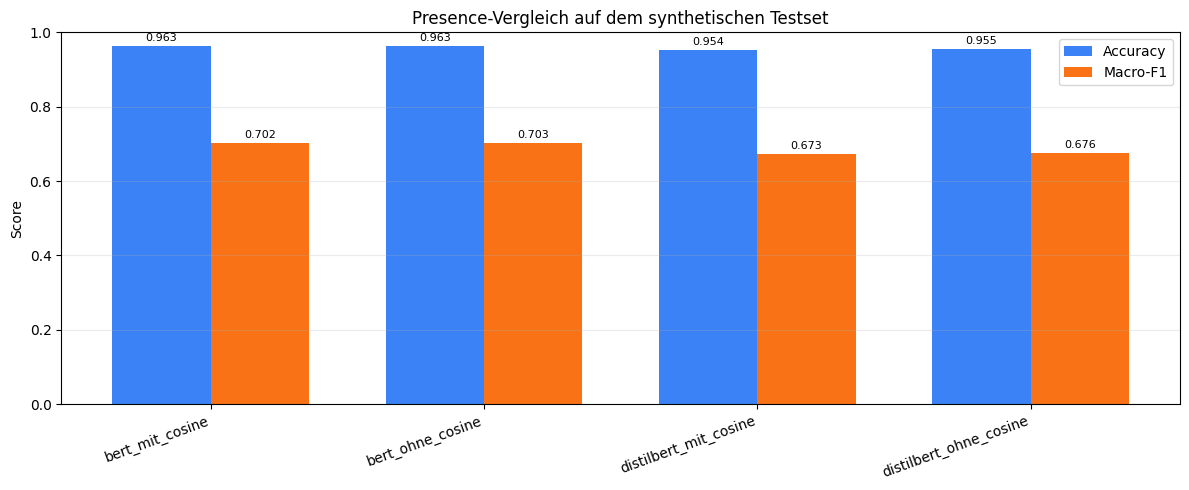

,experiment,encoder,accuracy,f1
0,bert_mit_cosine,BERT,0.9627,0.7019
1,bert_ohne_cosine,BERT,0.9632,0.7034
2,distilbert_mit_cosine,DistilBERT,0.9536,0.6733
3,distilbert_ohne_cosine,DistilBERT,0.9547,0.6757


In [21]:
# ---------------------------------------------------------------------------
# Korrelationen der positiven/negativen Mittelwerte und 8-Balken-Vergleich
# ---------------------------------------------------------------------------
# hier werden die echten Realdata-Werte und Modellwerte getrennt verglichen
correlation_rows = []
for (experiment_name, seed), arrays in realdata_arrays.items():
    person_subset = realdata_person_means[
        (realdata_person_means["experiment"] == experiment_name)
        & (realdata_person_means["seed"] == seed)
    ].copy()
    true_pos_neg = person_subset["y_pos_mean"].corr(person_subset["y_neg_mean"], method="pearson")
    pred_pos_neg = person_subset["pred_pos_mean"].corr(person_subset["pred_neg_mean"], method="pearson")
    true_pred_pos = person_subset["y_pos_mean"].corr(person_subset["pred_pos_mean"], method="pearson")
    true_pred_neg = person_subset["y_neg_mean"].corr(person_subset["pred_neg_mean"], method="pearson")
    true_pos_neg_spearman = person_subset["y_pos_mean"].corr(person_subset["y_neg_mean"], method="spearman")
    pred_pos_neg_spearman = person_subset["pred_pos_mean"].corr(person_subset["pred_neg_mean"], method="spearman")
    correlation_rows.append({
        "experiment": experiment_name,
        "seed": seed,
        "true_pos_neg_pearson": true_pos_neg,
        "pred_pos_neg_pearson": pred_pos_neg,
        "true_pos_neg_spearman": true_pos_neg_spearman,
        "pred_pos_neg_spearman": pred_pos_neg_spearman,
        "true_pred_pos_pearson": true_pred_pos,
        "true_pred_neg_pearson": true_pred_neg,
    })

# kKorrelation true_pos_neg gegen pred_pos_neg beantwortet die gewünschte Ähnlichkeitsfrage
correlation_results = pd.DataFrame(correlation_rows)
print("Korrelation der Personenmittelwerte von positiven und negativen Items:")
if correlation_results.empty:
    print("Noch keine vollständigen Modellläufe vorhanden; Korrelationen werden nach dem Training berechnet.")
else:
    display(correlation_results.round(3))

plot_rows = []
for run in all_runs:
    if run.get("best_test") is None:
        continue
    plot_rows.append({
        "experiment": run["name"],
        "encoder": ENCODER_CONFIGS[run["encoder"]]["label"],
        "seed": run["seed"],
        "accuracy": run["best_test"]["task1_accuracy"],
        "f1": run["best_test"]["task1_f1"],
    })

plot_results = pd.DataFrame(plot_rows)
if plot_results.empty:
    print("Noch keine vollständigen Testmetriken vorhanden; der Barplot wird nach dem Training erzeugt.")
else:
    plot_means = plot_results.groupby(["experiment", "encoder"])[["accuracy", "f1"]].mean().reset_index()
    x = np.arange(len(plot_means))
    width = 0.36
    fig, ax = plt.subplots(figsize=(12, 5))
    accuracy_bars = ax.bar(x - width / 2, plot_means["accuracy"], width, label="Accuracy", color="#3B82F6")
    f1_bars = ax.bar(x + width / 2, plot_means["f1"], width, label="Macro-F1", color="#F97316")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_means["experiment"], rotation=20, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title("Presence-Vergleich auf dem synthetischen Testset")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    for bars in (accuracy_bars, f1_bars):
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    plt.tight_layout()
    plt.show()

if not plot_results.empty:
    display(plot_means.round(4))

### Methodische Entscheidung: Baselines, Thresholds und Konfidenzintervalle

Die Baselines zeigen, ob das Modell die echten Daten besser vorhersagt als eine einfache Vorhersage aus dem synthetischen Training. Ohne diese Referenzen wäre ein MAE allein schwer einzuordnen.

Mehrere Presence-Thresholds machen den Zielkonflikt sichtbar: Ein niedriger Threshold erhöht meist die Coverage, kann aber mehr ungeeignete Likert-Vorhersagen einschließen. Ein hoher Threshold kann die conditional-Metriken verbessern, bewertet dann aber möglicherweise nur noch wenige Ratings. Daher sollte die Schwelle nicht ausschließlich nach MAE ausgewählt werden.

Die Ratings sind innerhalb einer Person nicht unabhängig. Deshalb werden die Bootstrap-Konfidenzintervalle nach `name` gruppiert. So werden ganze Personen-Gruppen gezogen und die Unsicherheit nicht durch wiederholte Aufnahmen derselben Person künstlich unterschätzt.

Hauptvergleich auf echten Daten (Mittelwert ueber Seeds):


,Likert MAE (↓),Likert RMSE (↓),Gerundete Accuracy (↑),Presence-Coverage (↑),Mittleres Item-QWK (↑)
experiment,,,,,
bert_mit_cosine,1.3444,1.6037,0.2095,0.1827,0.0865
bert_ohne_cosine,1.3443,1.6045,0.2047,0.1820,0.0767
distilbert_mit_cosine,1.2983,1.4979,0.1888,0.2006,0.1466
distilbert_ohne_cosine,1.2918,1.4925,0.1892,0.2017,0.1323


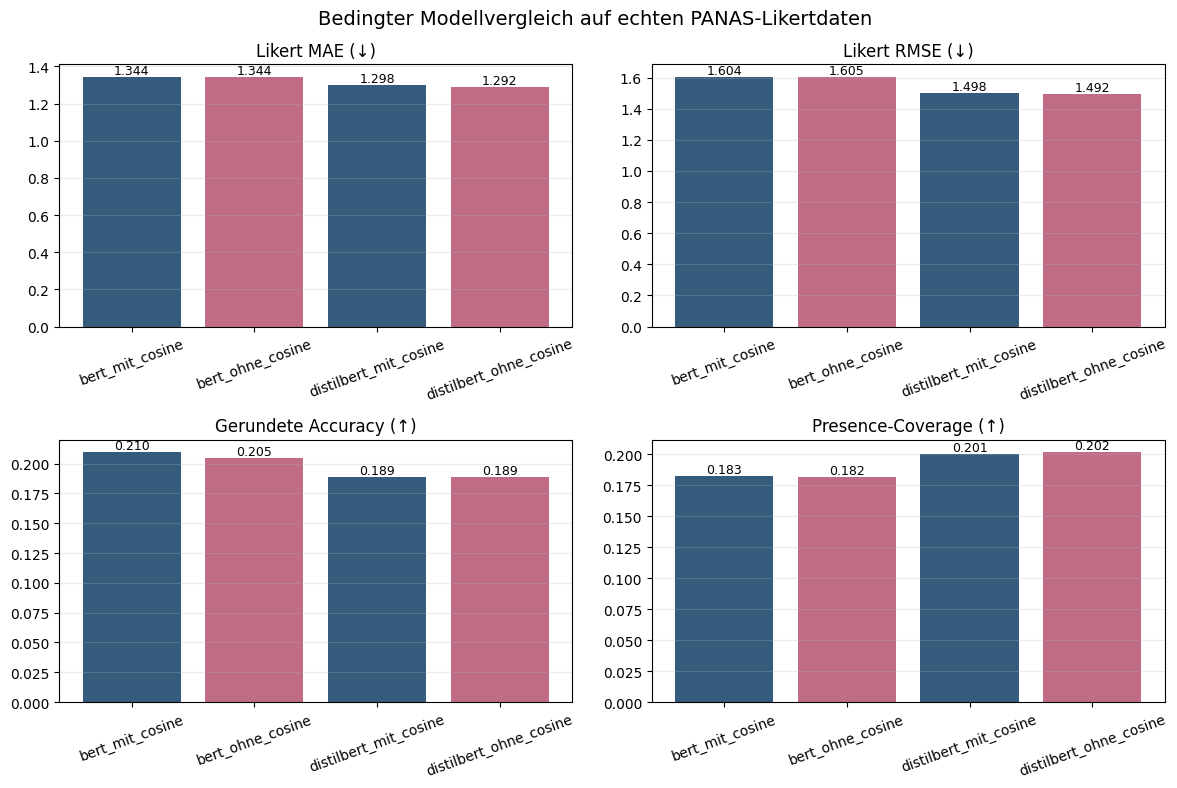

In [22]:
# ---------------------------------------------------------------------------
# Hauptvergleich auf Realdata: nur externe Likert-Validierung
# ---------------------------------------------------------------------------
# Die erweiterte Auswertung steht in der vorherigen Zelle. Diese Tabelle bleibt
# als kompakter Vergleich der bisherigen bedingten Metriken erhalten.
REAL_COMPARISON_METRICS = {
    "likert_mae": "Likert MAE (↓)",
    "likert_rmse": "Likert RMSE (↓)",
    "rounded_accuracy": "Gerundete Accuracy (↑)",
    "coverage": "Presence-Coverage (↑)",
    "mean_item_qwk": "Mittleres Item-QWK (↑)",
}

real_summary = real_validation_results.groupby("experiment")[list(REAL_COMPARISON_METRICS)].agg(["mean", "std"])
real_table = real_summary.xs("mean", axis=1, level=1).rename(columns=REAL_COMPARISON_METRICS)
print("Hauptvergleich auf echten Daten (Mittelwert ueber Seeds):")
display(
    real_table.style
    .format("{:.4f}")
    .highlight_min(subset=["Likert MAE (↓)", "Likert RMSE (↓)"], color="#d9ead3")
    .highlight_max(subset=["Gerundete Accuracy (↑)", "Presence-Coverage (↑)", "Mittleres Item-QWK (↑)"], color="#d9ead3")
    .set_caption("Bisherige bedingte Realdata-Validierung")
)

if {"ohne_cosine", "mit_cosine"} <= set(real_table.index):
    real_direct = pd.DataFrame({
        "ohne_cosine": real_table.loc["ohne_cosine"],
        "mit_cosine": real_table.loc["mit_cosine"],
    })
    real_direct["diff (mit - ohne)"] = real_direct["mit_cosine"] - real_direct["ohne_cosine"]
    real_direct["besser mit Cosine?"] = [
        (diff < 0) if metric in {"Likert MAE (↓)", "Likert RMSE (↓)"} else (diff > 0)
        for metric, diff in zip(real_direct.index, real_direct["diff (mit - ohne)"])
    ]
    print("Direkter Realdata-Vergleich:")
    display(real_direct.style.format({"ohne_cosine": "{:.4f}", "mit_cosine": "{:.4f}", "diff (mit - ohne)": "{:+.4f}"}))

plot_data = real_table.reset_index().melt(id_vars="experiment", var_name="metric", value_name="value")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.flat, ["Likert MAE (↓)", "Likert RMSE (↓)", "Gerundete Accuracy (↑)", "Presence-Coverage (↑)"]):
    values = plot_data[plot_data["metric"] == metric]
    bars = ax.bar(values["experiment"], values["value"], color=["#355c7d", "#c06c84"])
    ax.set_title(metric)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)
fig.suptitle("Bedingter Modellvergleich auf echten PANAS-Likertdaten", fontsize=14)
fig.tight_layout()
plt.show()

## 6. Vergleich: mit vs. ohne Cosine-Loss

Die synthetische Testauswertung dient nur zur Checkpoint-Auswahl. Der fachlich relevante Modellvergleich erfolgt anschliessend auf der externen Realdata-Validierung: bewertet werden ausschliesslich Likert-Werte fuer Items, die das Modell per Presence-Score erkannt hat. Presence selbst wird auf den Realdata nicht als Ground Truth bewertet.

In [23]:
# Synthetische Testmetriken am jeweils auf Validation ausgewählten Checkpoint.
METRIC_COLS = ["loss_main", "task1_f1", "task1_auroc", "task1_accuracy", "task2_mae", "task2_rmse"]
HIGHER_IS_BETTER = {"task1_f1", "task1_auroc", "task1_accuracy"}

synthetic_test_results = pd.DataFrame([
    {"experiment": r["name"], "seed": r["seed"], "best_epoch": r["best_test"]["epoch"],
     **{m: r["best_test"][m] for m in METRIC_COLS}}
    for r in all_runs
])
print("Synthetischer Testvergleich pro Lauf (Checkpoint auf Validation gewählt):")
display(synthetic_test_results.round(4))

synthetic_means = synthetic_test_results.groupby("experiment")[METRIC_COLS].mean()
print("\nMittelwert auf dem synthetischen Testset:")
display(synthetic_means.round(4))

if {"ohne_cosine", "mit_cosine"} <= set(synthetic_means.index):
    synthetic_comparison = pd.DataFrame({
        "ohne_cosine": synthetic_means.loc["ohne_cosine"],
        "mit_cosine": synthetic_means.loc["mit_cosine"],
    })
    synthetic_comparison["diff (mit - ohne)"] = synthetic_comparison["mit_cosine"] - synthetic_comparison["ohne_cosine"]
    synthetic_comparison["besser mit Cosine?"] = [
        (diff > 0) if metric in HIGHER_IS_BETTER else (diff < 0)
        for metric, diff in zip(synthetic_comparison.index, synthetic_comparison["diff (mit - ohne)"])
    ]
    print("\nDirekter synthetischer Testvergleich:")
    display(synthetic_comparison.round(4))

Synthetischer Testvergleich pro Lauf (Checkpoint auf Validation gewählt):


,experiment,seed,best_epoch,loss_main,task1_f1,task1_auroc,task1_accuracy,task2_mae,task2_rmse
0,bert_ohne_cosine,42,5,1.2483,0.6761,0.9829,0.9595,0.3832,0.6107
1,bert_mit_cosine,42,5,1.2447,0.6748,0.9827,0.9595,0.3777,0.6029
2,distilbert_ohne_cosine,42,5,1.7099,0.6429,0.9656,0.9488,0.3833,0.6906
3,distilbert_mit_cosine,42,5,1.7020,0.6415,0.9663,0.9480,0.3791,0.6821
4,bert_ohne_cosine,43,5,1.3064,0.7107,0.9753,0.9634,0.4208,0.6292
5,bert_mit_cosine,43,5,1.2971,0.7069,0.9763,0.9623,0.4155,0.6194
6,distilbert_ohne_cosine,43,5,1.5589,0.6806,0.9677,0.9555,0.3438,0.6244
7,distilbert_mit_cosine,43,5,1.5614,0.6820,0.9671,0.9555,0.3419,0.6204
8,bert_ohne_cosine,44,5,1.2065,0.7233,0.9780,0.9666,0.3703,0.5899
9,bert_mit_cosine,44,5,1.1955,0.7239,0.9779,0.9662,0.3652,0.5806



Mittelwert auf dem synthetischen Testset:


,loss_main,task1_f1,task1_auroc,task1_accuracy,task2_mae,task2_rmse
experiment,,,,,,
bert_mit_cosine,1.2458,0.7019,0.9790,0.9627,0.3861,0.6010
bert_ohne_cosine,1.2537,0.7034,0.9788,0.9632,0.3915,0.6099
distilbert_mit_cosine,1.6106,0.6733,0.9672,0.9536,0.3570,0.6435
distilbert_ohne_cosine,1.6120,0.6757,0.9670,0.9547,0.3595,0.6489


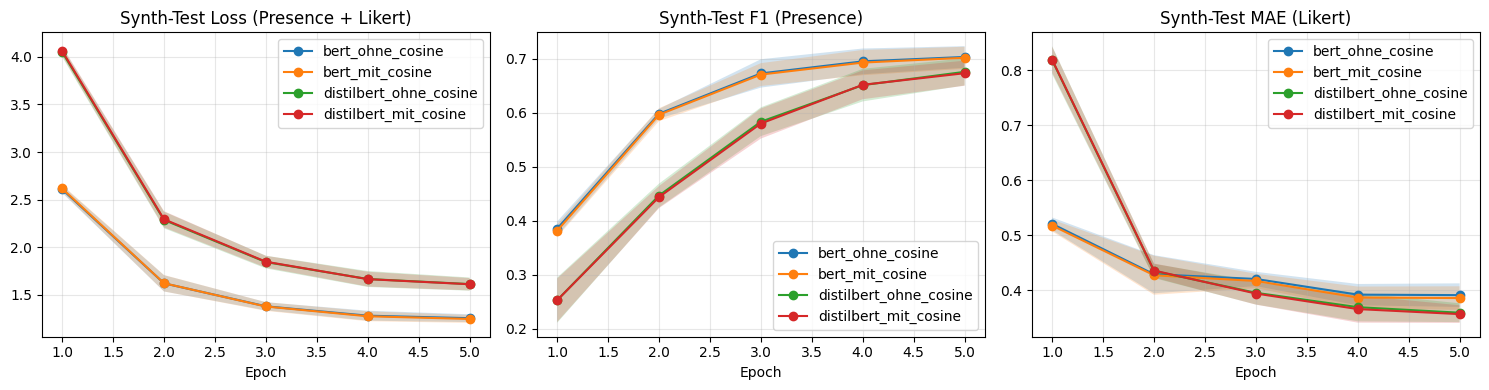

In [24]:
# Synthetische Testkurven pro Epoche (Mittelwert ueber Seeds, Band = Std.)
plot_metrics = [("loss_main", "Synth-Test Loss (Presence + Likert)"),
                ("task1_f1", "Synth-Test F1 (Presence)"),
                ("task2_mae", "Synth-Test MAE (Likert)")]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(15, 4))
for ax, (key, title) in zip(axes, plot_metrics):
    for name in EXPERIMENTS:
        curves = np.array([[h["test"][key] for h in r["history"]] for r in all_runs if r["name"] == name])
        mean, x = curves.mean(axis=0), np.arange(1, curves.shape[1] + 1)
        ax.plot(x, mean, marker="o", label=name)
        if len(curves) > 1:
            ax.fill_between(x, mean - curves.std(axis=0), mean + curves.std(axis=0), alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Bestes Modell laden (optional)

Lädt den besten Checkpoint der unten gewählten Variante (bester Seed nach `loss_main`).
Für einen Domain-Shift-Check auf `real_data.csv` kann mit diesem Modell `evaluate()` auf einem
entsprechend gebauten `DataLoader` laufen.

In [27]:
FINAL_EXPERIMENT = "bert_mit_cosine"

if not all_runs:
    print("Keine abgeschlossenen Modellläufe vorhanden. Bitte die Trainingszelle vollständig ausführen.")
    final_run = None
    best_model = None
else:
    matching_runs = [run for run in all_runs if run["name"] == FINAL_EXPERIMENT]
    if matching_runs:
        final_run = min(matching_runs, key=lambda run: run["best"]["loss_main"])
    else:
        final_run = min(all_runs, key=lambda run: run["best"]["loss_main"])
        print(
            f"'{FINAL_EXPERIMENT}' wurde nicht gefunden. "
            f"Verwende stattdessen den besten vorhandenen Lauf: {final_run['name']}"
        )

    best_model = BertMultiTaskModel(final_run["model_name"], num_items=NUM_ITEMS).to(device)
    best_model.load_state_dict(torch.load(final_run["ckpt_path"], map_location=device))
    best_model.eval()
    print(f"Geladen: {final_run['ckpt_path']} (Epoch {final_run['best']['epoch']})")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Geladen: best_bert_mit_cosine_seed44.pt (Epoch 5)


In [28]:
# ---------------------------------------------------------------------------
# Itemweise Auswertung des besten Modells
# ---------------------------------------------------------------------------
def report_best_model_item_metrics():
    if not all_runs:
        print("Noch kein abgeschlossener Modelllauf vorhanden. Training zuerst vollständig ausführen.")
        return

    # Bestes Modell nach der synthetischen Validation: niedrigster loss_main.
    best_run = min(all_runs, key=lambda run: run["best"]["loss_main"])
    _, _, _, best_test_loader, best_real_loader = build_model_loaders(best_run["model_name"])
    best_model = BertMultiTaskModel(best_run["model_name"], num_items=NUM_ITEMS).to(device)
    best_model.load_state_dict(torch.load(best_run["ckpt_path"], map_location=device))
    best_model.eval()

    # Presence-F1 pro Item auf dem synthetischen Testsplit.
    test_presence_true, test_presence_pred = [], []
    with torch.no_grad():
        for batch in best_test_loader:
            batch = _to_device(batch, device)
            presence_logits, _, _ = best_model(batch["input_ids"], batch["attention_mask"])
            presence_prob = torch.sigmoid(presence_logits).cpu().numpy()
            test_presence_true.append(batch["target_mask"].cpu().numpy())
            test_presence_pred.append((presence_prob >= REAL_PRESENCE_THRESHOLD).astype(np.float32))

    test_presence_true = np.concatenate(test_presence_true, axis=0).astype(int)
    test_presence_pred = np.concatenate(test_presence_pred, axis=0).astype(int)
    presence_f1_by_item = pd.DataFrame({
        "item": PANAS_ITEMS,
        "F1": [
            f1_score(test_presence_true[:, item_index], test_presence_pred[:, item_index], zero_division=0)
            for item_index in range(NUM_ITEMS)
        ],
    })

    # Oracle-Likert-MAE und -RMSE pro Item auf allen gültigen Realdata-Ratings.
    real_y_pred, _ = _predict_real_arrays(best_model, best_real_loader)
    real_y_true = real_target_values
    real_valid = real_target_mask.astype(bool)
    oracle_likert_by_item = pd.DataFrame({
        "item": REAL_PANAS_COLUMNS,
        "MAE": [
            mean_absolute_error(real_y_true[real_valid[:, item_index], item_index], real_y_pred[real_valid[:, item_index], item_index])
            if real_valid[:, item_index].any() else np.nan
            for item_index in range(NUM_ITEMS)
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(real_y_true[real_valid[:, item_index], item_index], real_y_pred[real_valid[:, item_index], item_index]))
            if real_valid[:, item_index].any() else np.nan
            for item_index in range(NUM_ITEMS)
        ],
    })

    print(f"Bestes Modell: {best_run['name']} | Seed={best_run['seed']} | Epoch={best_run['best']['epoch']}")
    print(f"Presence-F1 je Item auf dem synthetischen Testset (Threshold={REAL_PRESENCE_THRESHOLD:.2f}):")
    display(presence_f1_by_item.round(4))
    print("Oracle-Likert-MAE und RMSE je Item auf der Realdata:")
    display(oracle_likert_by_item.round(4))

    del best_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


report_best_model_item_metrics()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-german-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bestes Modell: bert_ohne_cosine | Seed=44 | Epoch=5
Presence-F1 je Item auf dem synthetischen Testset (Threshold=0.50):


,item,F1
0,aktiv,0.8824
1,bekuemmert,0.6818
2,interessiert,0.9167
3,freudig_erregt,0.8408
4,veraergert,0.8846
5,stark,0.8276
6,schuldig,0.0000
7,erschrocken,0.0000
8,feindselig,0.9524
9,angeregt,0.8936


Oracle-Likert-MAE und RMSE je Item auf der Realdata:


,item,MAE,RMSE
0,aktiv,1.0920,1.3657
1,bekümmert,1.1556,1.3491
2,interessiert,1.8101,2.1285
3,freudig erregt,1.2112,1.5604
4,verärgert,0.9822,1.1384
5,stark,1.3865,1.7071
6,schuldig,0.3130,0.7281
7,erschrocken,0.4730,0.8947
8,feindselig,0.6322,0.8247
9,angeregt,1.1501,1.3918
